## Telco Customer Churn Analysis

Customer churn is an important problem for telecom companies because losing existing customers can have a direct impact on revenue. In this project, I analysed customer data to understand the factors associated with churn and identify the types of customers who are more likely to leave.

I started by exploring the data and looking at churn across different customer groups. From there, I built and compared classification models to see how well customer churn could be predicted.

## Business Problem

Customer churn can have a direct impact on a telecom company's revenue. If we can identify customers who are more likely to leave, the company can focus its retention efforts on those customers.

The main questions I want to answer are:

* Which customer characteristics are associated with higher churn?
* Which customer groups are more likely to leave?
* Can a model identify customers who are likely to churn?
* What does the model rely on when making its predictions?
* Where does the model make mistakes, particularly which churners does it fail to identify?

For this analysis, missing a customer who eventually churns is more concerning than incorrectly flagging a customer who stays. However, too many false positives would also mean that retention efforts are being spent on customers who may not actually be at risk.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
pd.set_option("display.max_columns", None)

## Understanding the Data

The dataset contains 7,043 customers and 21 columns. It includes information about customer demographics, services, contract type, payment method, charges, and whether the customer churned.

Before starting the analysis, I checked the structure of the data, missing values, and duplicates. I also removed `customerID` since it is only an identifier and does not provide useful information for predicting churn.

Finally, I converted the `Churn` column from Yes/No into 1/0 so it could be used more easily in the analysis and modelling.


In [5]:
data.shape

(7043, 21)

In [6]:
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
data.drop("customerID", axis = 1, inplace= True)

In [10]:
data["Churn"] = (data["Churn"] == "Yes").astype(int)

## Exploratory Data Analysis

### Overall Churn Rate

Before looking at individual customer characteristics, I first checked the overall churn rate. This gives a baseline for comparing the different customer groups later.The overall churn rate gives a starting point for the analysis. Most customers stayed with the company, while a smaller proportion churned. I used this as a baseline when comparing churn across different customer groups.


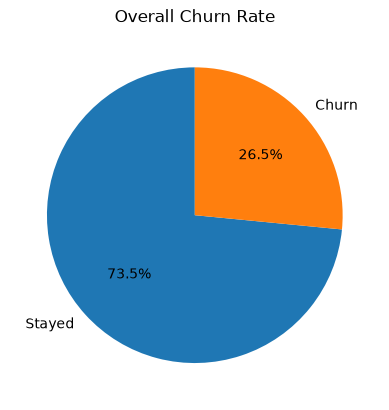

In [11]:
churn_rate = data.Churn.value_counts()
labels = churn_rate.index.map({0 : "Stayed", 1 : "Churn"})
plt.pie(churn_rate, autopct= "%1.1f%%",
       labels= labels,
       startangle=90)
plt.title("Overall Churn Rate")
plt.show()

# Churn Across Customer Groups

### Churn Rate by Contract Type

The first major difference appeared when I compared customers by contract type. Month-to-month customers had a much higher churn rate than customers on longer contracts.

Because of this large difference, I decided to focus most of the deeper analysis on month-to-month customers rather than treating all customers as one group.

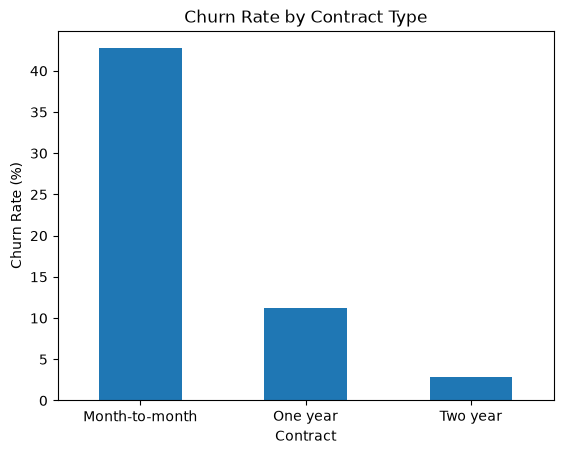

In [12]:
(data.groupby("Contract")["Churn"].mean()*100).plot(kind="bar", rot=0)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

### Churn Rate by Tenure

I then looked at tenure because churn was much higher among newer customers. The results showed a clear downward pattern: customers with shorter tenure had higher churn, while churn decreased as customers stayed longer. I also checked if this pattern existed within month-to-month contract type.

In [13]:
data["TenureGroup"] = pd.cut(data["tenure"],
    bins =[ 0,3,6,12,24,48,72],
    labels= ["0-3","4-6","7-12","13-24","25-48","49-72"],
    include_lowest=True)

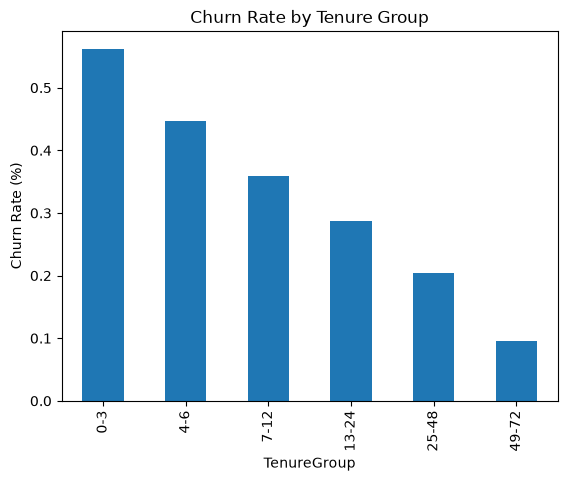

In [14]:
(data.groupby("TenureGroup").Churn.mean()).plot(kind = "bar")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group")
plt.show()

In [15]:
data_m2m = data[data["Contract"] == "Month-to-month"]

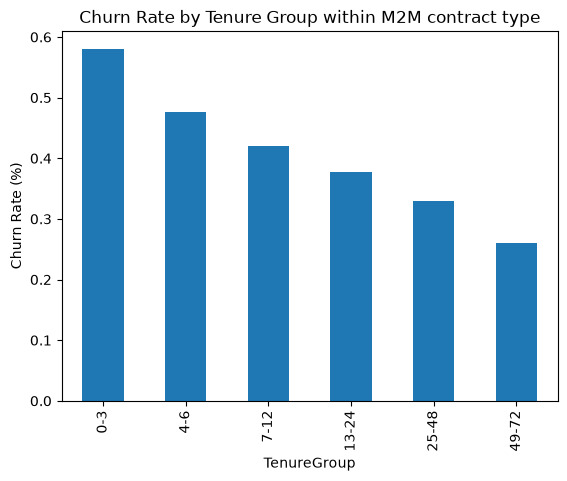

In [16]:
(data_m2m.groupby("TenureGroup").Churn.mean()).plot(kind = "bar")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group within M2M contract type")
plt.show()

## Service Count and Churn

Customers using more services generally had lower churn. However, the 0-service group did not follow the pattern I initially expected, so I looked deeper into what makes up this group.

In [17]:
columns = ["Partner","Dependents","PhoneService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
           "TechSupport", "StreamingTV", "StreamingMovies"]
for i in columns:
    data[i] = data[i].str.strip()
    data[i] = data[i].map({"No" : 0, "Yes" : 1, "No internet service" : 0})

In [18]:
data["ServiceCount"] = (data["OnlineSecurity"] + data["OnlineBackup"] + data["DeviceProtection"] + data["TechSupport"]
+ data["StreamingTV"] + data["StreamingMovies"])

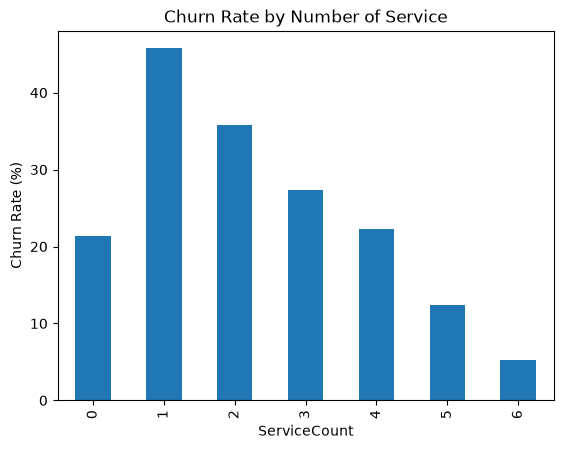

In [19]:
(data.groupby("ServiceCount").Churn.mean()*100).plot(kind = "bar")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Number of Service")
plt.show()

### Understanding the 0-Service Group

The 0-service group initially looked unusual because its churn rate was only 21.4%, despite customers with 1 service having a much higher churn rate.

I therefore broke the group down by internet service. This showed that the 0-service group contains customers with very different churn behaviour. Customers with no internet service had a much lower churn rate, which pulls the overall churn rate of the 0-service group down.

This showed me that looking only at ServiceCount was not enough.

In [20]:
summ = (data.groupby(["ServiceCount", "InternetService"]).agg(Customers = ("Churn", "count"),
                                                           ChurnRate = ("Churn", lambda x :x.mean()*100))).reset_index()

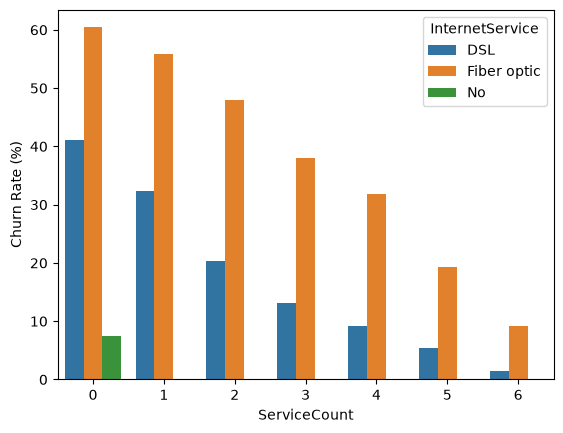

In [21]:
sns.barplot(
    data=summ, x="ServiceCount", y="ChurnRate", hue="InternetService"
)
plt.ylabel("Churn Rate (%)")
plt.show()

### Fiber Churn and Tenure

Fiber customers also showed a strong decrease in churn as tenure increased. I initially considered whether the high churn among fiber customers was simply because there were many new fiber customers.

To check this, I controlled for tenure and compared fiber customers within the same tenure groups. Fiber customers still showed higher churn across the tenure groups.

This suggests that the high churn among fiber customers cannot be explained by tenure alone.

In [22]:
fiber_dsl =(data[data["InternetService"].isin(["DSL", "Fiber optic"])].groupby(
    ["TenureGroup", "InternetService"]
)["Churn"].mean() * 100).reset_index()

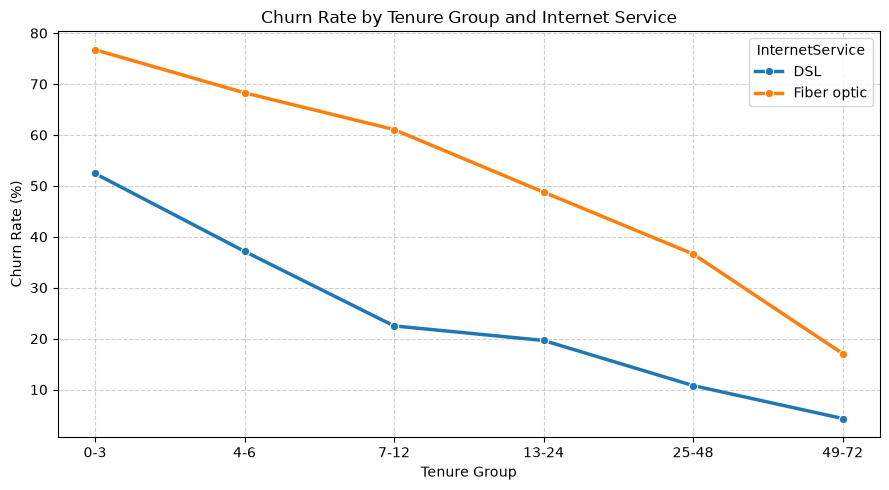

In [23]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=fiber_dsl,
    x="TenureGroup",
    y="Churn",
    hue="InternetService",
    marker="o",
    linewidth=2.5,
)

plt.title("Churn Rate by Tenure Group and Internet Service", fontsize=12)
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

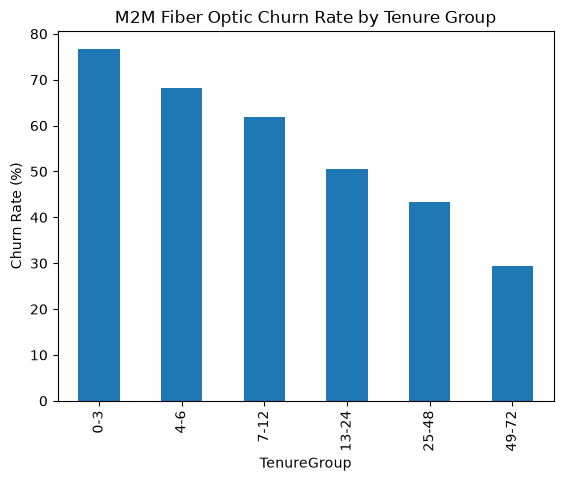

In [24]:
m2m_data_fiber = data_m2m[data_m2m["InternetService"] =="Fiber optic"]

(m2m_data_fiber.groupby("TenureGroup").Churn.mean()*100).plot(kind = "bar")
plt.ylabel("Churn Rate (%)")
plt.title("M2M Fiber Optic Churn Rate by Tenure Group")
plt.show()

### Churn by Service Count Among Fiber Customers

Churn generally appears to decrease as the number of services increases among fiber customers.

In [25]:
fiber_servicecount = (data.groupby(["ServiceCount", "InternetService"]).agg(Customers = ("Churn", "count"),
                                                           ChurnRate = ("Churn", lambda x: x.mean()*100))).reset_index()

In [26]:
fiber_df = fiber_servicecount[
    fiber_servicecount["InternetService"] == "Fiber optic"
]

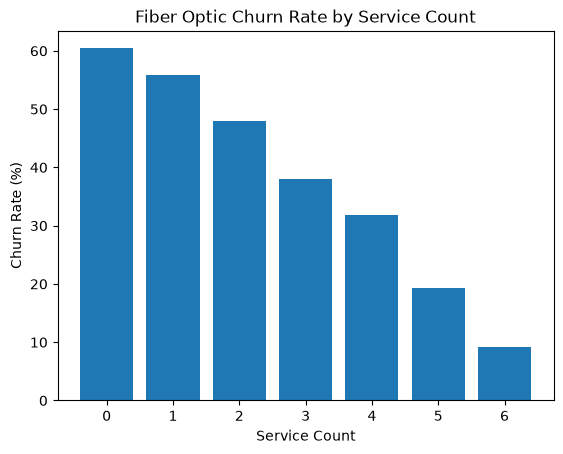

In [27]:
plt.bar(
    fiber_df["ServiceCount"],
    fiber_df["ChurnRate"],
)

plt.title("Fiber Optic Churn Rate by Service Count")
plt.xlabel("Service Count")
plt.ylabel("Churn Rate (%)")
plt.show()

## Add-on Services and Churn

I initially expected customers with add-on services to be less likely to churn because having more services could indicate greater engagement with the company.

However, the results did not support this. Customers with at least one add-on service actually had a higher churn rate than customers without add-on services.

Because of this result, I did not continue with the assumption that add-on services reduce churn.

In [28]:
data["AdOnServices"] = (data["ServiceCount"] > 0).map({False : "No", True : "Yes"})

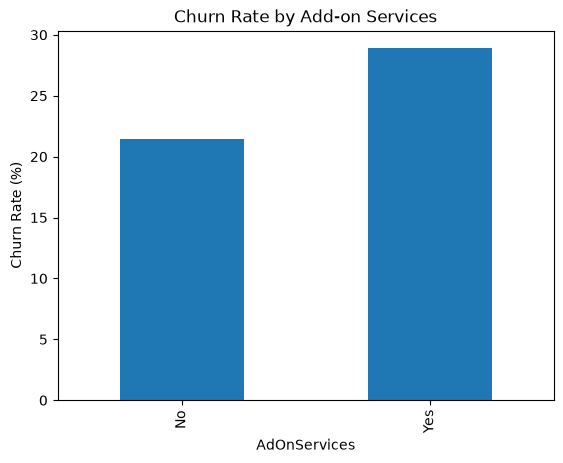

In [29]:
(data.groupby("AdOnServices").Churn.mean()*100).plot(kind = "bar")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Add-on Services")
plt.show()

## Monthly Charges and Churn Among Month-to-Month Customers

Within M2M customers, churned customers had higher average monthly charges than customers who stayed across the tenure groups.

In [30]:
monthly_df = (data_m2m.groupby(["TenureGroup", "Churn"]).MonthlyCharges.mean()).reset_index()
monthly_df.Churn = monthly_df.Churn.map({0 : "Stayed", 1 : "Churn"})

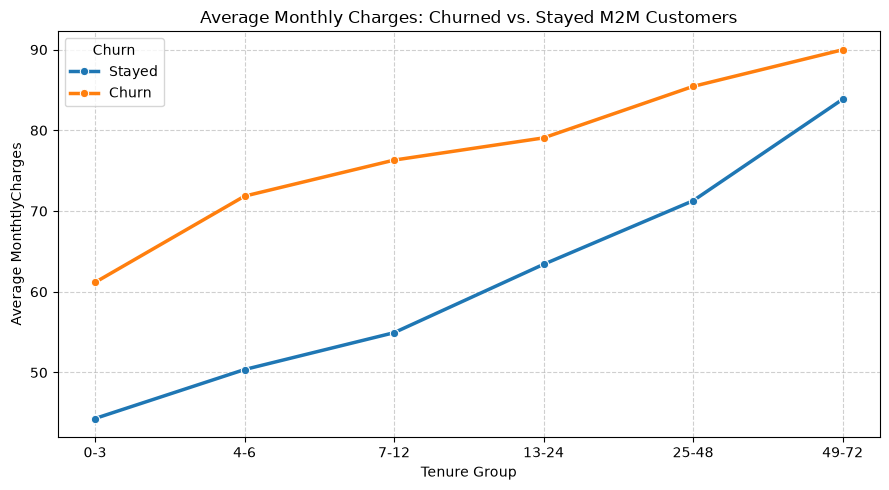

In [31]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=monthly_df,
    x="TenureGroup",
    y="MonthlyCharges",
    hue="Churn",
    marker="o",
    linewidth=2.5,
)

plt.title("Average Monthly Charges: Churned vs. Stayed M2M Customers", fontsize=12)
plt.xlabel("Tenure Group")
plt.ylabel("Average MonthtlyCharges")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Key Findings

From the analysis, a few patterns stood out:

- Month-to-month customers have the highest churn rate, so most of the deeper analysis was focused on this group.
- Churn is much higher among newer customers, and the churn rate generally decreases as tenure increases.
- Fiber optic customers have a higher churn rate than DSL customers. Looking at tenure groups showed that tenure alone does not explain this difference.
- Within month-to-month customers, customers who churned had higher average monthly charges than customers who stayed. However, this does not necessarily mean that price is the reason they churned, since the difference could be related to the services or packages they use.
- The analysis did not show that simply having more add-on services reduces churn. The relationship between service count and churn is more complicated and depends on the type of services customers use.

# Modelling

I then built a few classification models to see how well customer information can be used to identify customers who are likely to churn.

I compared Logistic Regression, Random Forest, and XGBoost. Since missing a customer who churns is more concerning in this case, I focused on recall while also looking at precision and F1 score.

I used stratified cross-validation so that the proportion of churned customers was kept similar across the folds.


In [32]:
df = data.copy()

In [33]:
df.drop('TenureGroup', axis =1, inplace=True)

In [34]:
df['MultipleLines'] = df['MultipleLines'].map({'No' : 0, 'No phone service' : 0, 'Yes' : 1})

In [35]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [36]:
df.loc[df['tenure'] == 0, 'TotalCharges'] = df['MonthlyCharges']

In [37]:
df.drop(['MonthlyCharges','TotalCharges'], axis =1, inplace=True)

In [38]:
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix,f1_score, make_scorer
from sklearn.preprocessing import StandardScaler

In [39]:
X = df.drop('Churn', axis = 1)
y = df['Churn']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state=42,
                                                    stratify=y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
scoring = {'recall': 'recall', 'precision':'precision', 'f1':'f1'}

In [42]:
categoricacl_cols = df.select_dtypes(include='object').columns
numerical_cols = ['tenure', 'ServiceCount']

In [43]:
cat_trans = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

num_trans = Pipeline(steps=[
    ('scaler', StandardScaler())])

In [44]:
preprocessor = ColumnTransformer(transformers=[ 
    ('cat', cat_trans, categoricacl_cols),
    ('num', num_trans, numerical_cols)], remainder='passthrough')

In [45]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))])

In [46]:
results = cross_validate(clf, X_train, y_train, cv=skf, scoring = scoring)

In [47]:
print('Recall: ', results['test_recall'])
print('Precision: ', results['test_precision'])
print('F1: ', results['test_f1'])

Recall:  [0.81270903 0.74247492 0.78595318 0.8361204  0.77591973]
Precision:  [0.54241071 0.49553571 0.50321199 0.52521008 0.53579677]
F1:  [0.65060241 0.59437751 0.61357702 0.64516129 0.63387978]


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

In [49]:
results2 = cross_validate(rf_model, X_train, y_train, cv=skf, scoring = scoring)

In [50]:
print('Recall: ', results2['test_recall'])
print('Precision: ', results2['test_precision'])
print('F1: ', results2['test_f1'])

Recall:  [0.66889632 0.58862876 0.64548495 0.64548495 0.66889632]
Precision:  [0.53908356 0.52694611 0.53760446 0.54985755 0.56657224]
F1:  [0.59701493 0.55608215 0.58662614 0.59384615 0.61349693]


In [51]:
from xgboost import XGBClassifier

In [52]:
neg, pos = np.bincount(y_train)
scale = neg/pos

In [53]:
X_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric = 'logloss',
        scale_pos_weight = scale
    ))])

In [54]:
results3 = cross_validate(X_model, X_train, y_train, cv=skf, scoring = scoring)

In [55]:
print('Recall: ', results3['test_recall'])
print('Precision: ', results3['test_precision'])
print('F1: ', results3['test_f1'])

Recall:  [0.77926421 0.71237458 0.75585284 0.81605351 0.78929766]
Precision:  [0.52359551 0.51201923 0.51131222 0.53863135 0.53514739]
F1:  [0.62634409 0.5958042  0.6099865  0.64893617 0.63783784]


# Parameter Tuning

After comparing the models, I tuned the Logistic Regression model because it had the strongest recall during cross-validation.

I used GridSearchCV to test different values of C, solver, and max_iter. Since recall is the main metric for this analysis, I used recall as the scoring metric when selecting the best combination.


In [56]:
param_grid = {
    'classifier__C' : [0.01, 0.1, 1, 10, 100],
    'classifier__solver' : ['lbfgs', 'saga'],
    'classifier__max_iter' : [1000, 5000]}

In [57]:
recall_scorer = make_scorer(recall_score, pos_label = 1)

In [58]:
grid = GridSearchCV(
    clf,
    param_grid,
    cv = 5,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=2)

In [59]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__max_iter': [1000, 5000], 'classifier__solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(r..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`s

In [60]:
print ('Best Recal:', grid.best_score_)
print ('Best Params:', grid.best_params_)
       

Best Recal: 0.7986622073578595
Best Params: {'classifier__C': 0.01, 'classifier__max_iter': 1000, 'classifier__solver': 'lbfgs'}


# Final Model Performance

After tuning the Logistic Regression model, I used the best parameter combination to train the final model.

The final model uses C = 0.01, the lbfgs solver, max_iter = 1000, and balanced class weights. I then evaluated it on the test set that was kept separate from the training and tuning process.

The final model identified about 79% of the customers who actually churned. However, precision was lower at about 51%, meaning that a fair number of customers predicted to churn did not actually churn.

The confusion matrix shows 77 false negatives and 289 false positives. Since the main goal was to avoid missing customers who churn, I consider the recall more important here than accuracy alone.






In [61]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, C=0.01,
                                      solver='lbfgs',
                                      class_weight='balanced', random_state=42))])

In [62]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','ServiceCount', 'AdOnServices']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [63]:
y_pred = final_model.predict(X_test)

In [64]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print ("F1_scre:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7402413058907026
Precision: 0.5068259385665529
Recall: 0.7941176470588235
F1_scre: 0.61875

Confusion Matrix:
[[746 289]
 [ 77 297]]


# Model Interpretation

### What does the Logistic Regression model rely on?

After evaluating the final model, I looked at the Logistic Regression coefficients to understand which features were associated with higher or lower predicted churn.

The size of a coefficient shows how strongly the feature affects the model's prediction, while the sign shows the direction of the relationship. I sorted the coefficients by their absolute value to see which features had the largest influence on the model.


In [65]:
log = final_model.named_steps['classifier']

In [66]:
feat_names = final_model.named_steps['preprocessor'].get_feature_names_out()

In [67]:
coef = log.coef_[0]

In [68]:
coef_df = pd.DataFrame({
    'Feature': feat_names,
    'coeff': coef})

In [69]:
coef_df['abs_coeff'] = np.abs(coef)

In [70]:
coef_df.sort_values('abs_coeff', ascending=False)

,Feature,coeff,abs_coeff
16,num__tenure,-0.671675,0.671675
3,cat__InternetService_Fiber optic,0.603305,0.603305
5,cat__Contract_Month-to-month,0.553320,0.553320
4,cat__InternetService_No,-0.509475,0.509475
7,cat__Contract_Two year,-0.432766,0.432766
12,cat__PaymentMethod_Electronic check,0.313615,0.313615
23,remainder__OnlineSecurity,-0.262083,0.262083
28,remainder__StreamingMovies,0.236837,0.236837
27,remainder__StreamingTV,0.228137,0.228137
26,remainder__TechSupport,-0.222984,0.222984


### Which features are most important to the model?

I also used permutation importance to check which original features had the biggest effect on the model's F1 score.

Tenure had the largest importance, followed by contract type and internet service. This is broadly consistent with the earlier analysis, where tenure, contract type, and internet service showed some of the clearest differences in churn.


In [71]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df

,Feature,importance_mean,importance_std
4,tenure,0.088241,0.008832
14,Contract,0.031050,0.008716
7,InternetService,0.023772,0.008649
16,PaymentMethod,0.010254,0.005068
8,OnlineSecurity,0.006596,0.004983
6,MultipleLines,0.003776,0.002869
3,Dependents,0.002066,0.003897
1,SeniorCitizen,0.001877,0.002192
12,StreamingTV,0.001820,0.005237
17,ServiceCount,0.001490,0.002325


### Understanding the model with SHAP

I used SHAP to look more closely at how the model's features contribute to its predictions.

Unlike the coefficient analysis, SHAP shows how the features contribute across individual observations, so I used the overall plots to see which features have the strongest influence and whether they tend to push predictions towards or away from churn.


In [72]:
import shap

In [73]:
preprocessor = final_model.named_steps['preprocessor']
classifier = final_model.named_steps['classifier']


X_test_transformed = preprocessor.transform(X_test)


feature_names = preprocessor.get_feature_names_out()

print(X_test_transformed.shape)
print(len(feature_names))

(1409, 29)
29


In [74]:
explainer = shap.LinearExplainer(
    classifier,
    X_test_transformed
)

shap_values = explainer(X_test_transformed)

print(shap_values.shape)

Background dataset has 1409 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1409 when initializing the masker.


(1409, 29)


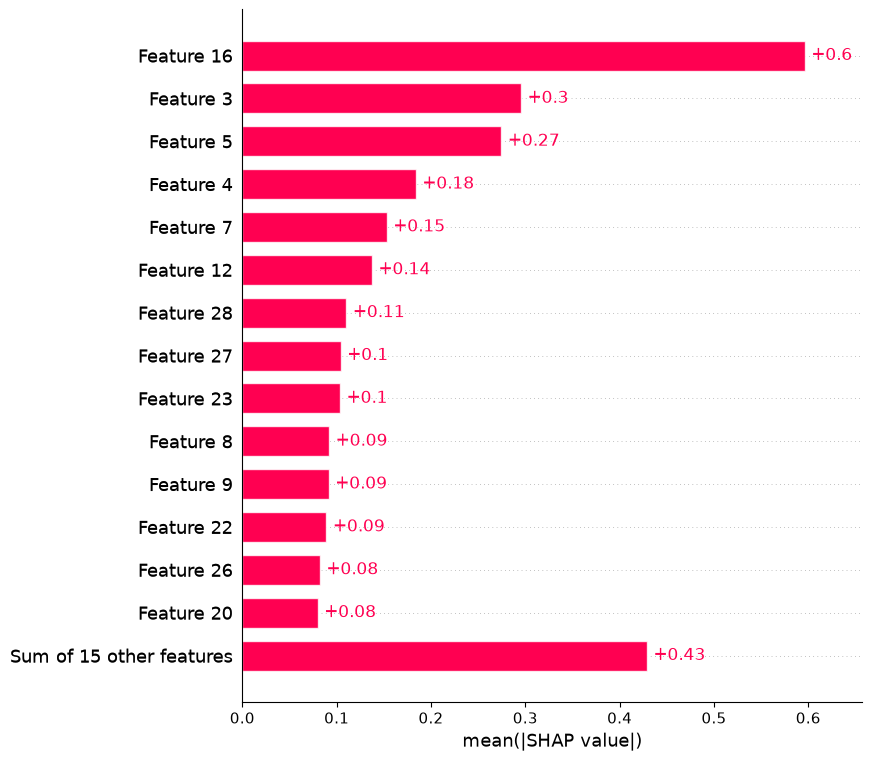

In [75]:
shap.plots.bar(shap_values, max_display=15)

In [76]:
for i, name in enumerate(feature_names):
    print(i, name)

0 cat__gender_Female
1 cat__gender_Male
2 cat__InternetService_DSL
3 cat__InternetService_Fiber optic
4 cat__InternetService_No
5 cat__Contract_Month-to-month
6 cat__Contract_One year
7 cat__Contract_Two year
8 cat__PaperlessBilling_No
9 cat__PaperlessBilling_Yes
10 cat__PaymentMethod_Bank transfer (automatic)
11 cat__PaymentMethod_Credit card (automatic)
12 cat__PaymentMethod_Electronic check
13 cat__PaymentMethod_Mailed check
14 cat__AdOnServices_No
15 cat__AdOnServices_Yes
16 num__tenure
17 num__ServiceCount
18 remainder__SeniorCitizen
19 remainder__Partner
20 remainder__Dependents
21 remainder__PhoneService
22 remainder__MultipleLines
23 remainder__OnlineSecurity
24 remainder__OnlineBackup
25 remainder__DeviceProtection
26 remainder__TechSupport
27 remainder__StreamingTV
28 remainder__StreamingMovies


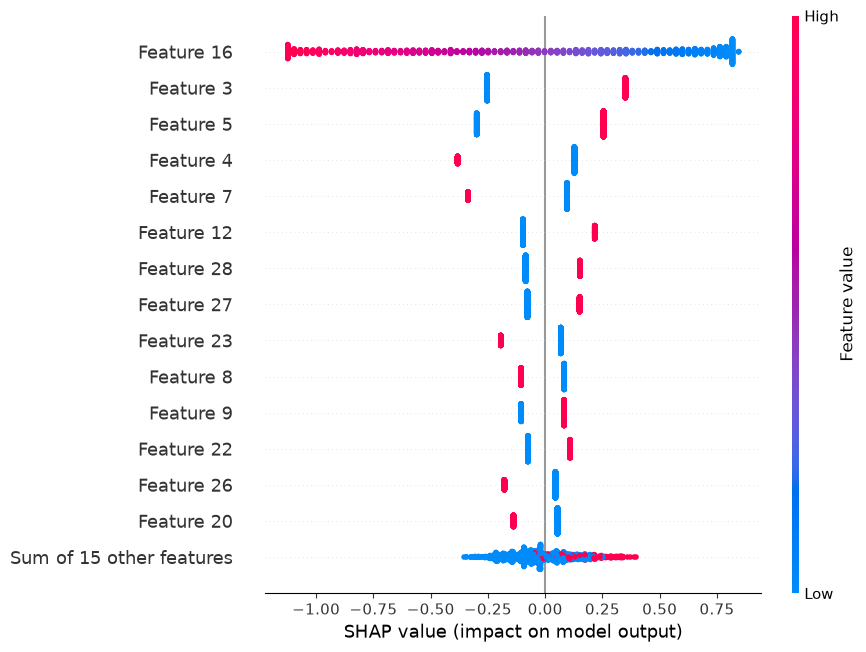

In [77]:
shap.plots.beeswarm(shap_values, max_display=15)

### Error Analysis

After looking at how the model makes its predictions, I wanted to see where those predictions were wrong.

I focused mainly on false negatives because these are customers who actually churned but were predicted to stay. I then compared the errors across contract types and tenure to see whether some groups were harder for the model to identify.


In [78]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

error_df = X_test.copy()

error_df['actual'] = y_test.values
error_df['predicted'] = y_pred
error_df['probability'] = y_prob

error_df['error_type'] = np.select(
    [
        (error_df['actual'] == 1) & (error_df['predicted'] == 0),
        (error_df['actual'] == 0) & (error_df['predicted'] == 1)
    ],
    [
        'False Negative',
        'False Positive'
    ],
    default='Correct'
)

In [79]:
error_df['error_type'].value_counts()

error_type
Correct           1043
False Positive     289
False Negative      77
Name: count, dtype: int64

In [80]:
pd.crosstab(
    error_df['Contract'],
    error_df['error_type']
)

error_type,Correct,False Negative,False Positive
Contract,,,
Month-to-month,459,38,276
One year,257,30,13
Two year,327,9,0


In [81]:
churners = error_df[error_df['actual'] == 1]

pd.crosstab(
    churners['Contract'],
    churners['error_type']
)

error_type,Correct,False Negative
Contract,,
Month-to-month,291,38
One year,6,30
Two year,0,9


In [82]:
contract_error = pd.crosstab(
    churners['Contract'],
    churners['error_type']
)

contract_error['FN_rate'] = (
    contract_error['False Negative'] /
    contract_error.sum(axis=1)
)

contract_error

error_type,Correct,False Negative,FN_rate
Contract,,,
Month-to-month,291,38,0.115502
One year,6,30,0.833333
Two year,0,9,1.000000


In [83]:
churners.groupby('error_type')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
error_type,,,,,,,,
Correct,297.0,12.333333,14.279072,1.0,2.0,6.0,18.0,66.0
False Negative,77.0,32.389610,24.200454,1.0,6.0,35.0,55.0,72.0


In [84]:
churners.groupby(['Contract', 'error_type'])['tenure'].mean()

Contract        error_type    
Month-to-month  Correct           12.075601
                False Negative    16.552632
One year        Correct           24.833333
                False Negative    44.266667
Two year        False Negative    59.666667
Name: tenure, dtype: float64

### Longer-Tenure Churners Are Harder to Identify

The error analysis showed that the model was much more likely to miss churners with longer tenure.

Among customers who actually churned, those correctly identified had an average tenure of about 12 months, while the customers missed by the model had an average tenure of about 32 months.

This suggests that the model is better at identifying the more obvious churn patterns among newer customers, but has more difficulty identifying customers who churn after staying with the company for longer.


# Limitations

There are some things this analysis cannot tell us.

- The analysis shows relationships between variables and churn, but it cannot tell us that one variable directly causes customers to leave.
- The dataset does not contain some information that could help explain why customers churn, such as customer satisfaction, complaints, service quality, outages, or offers from competitors.
- Some of the relationships could still be influenced by other variables that were not controlled for in every comparison.
- The data is historical, so the patterns found here may not remain the same if customer behaviour or the company's situation changes.

# Business Recommendations

Based on the findings, I would recommend that the company:

### Focus more on new month-to-month customers

Since month-to-month customers have the highest churn and churn is also higher among newer customers, the company should pay more attention to customers during the early stages of their relationship with the company. Improving onboarding and early customer support could be worth investigating.

### Investigate why fiber optic customers churn more

Fiber optic customers showed higher churn even when looking across different tenure groups. The company should investigate whether this is related to service quality, pricing, customer complaints, outages, or other factors that are not available in this dataset.

### Investigate the reason behind the higher charges among churned M2M customers

Churned M2M customers have higher average monthly charges than those who stayed. However, I would not recommend reducing prices based on this finding alone. The company should first check whether the difference is coming from the specific services or packages these customers subscribe to.

### Look at specific service combinations rather than simply adding more services

The analysis did not show that customers with more add-on services automatically have lower churn. It would be more useful to investigate which specific services or combinations of services are associated with lower churn.

### Do not focus only on newer customers when identifying churn risk

The model was better at identifying churn among newer customers but had more difficulty identifying customers who churned after staying longer. This suggests that retention efforts should not rely only on the patterns seen among newer customers, and further investigation is needed to understand why longer-tenure customers leave.

# Conclusion

This analysis showed that customer churn is strongly associated with contract type and tenure. Month-to-month customers had the highest churn rate, while newer customers were more likely to leave. Fiber optic customers also showed higher churn, although the analysis did not show that tenure alone explained this difference.

The Logistic Regression model was the strongest of the models tested based on recall. The final model identified about 79% of customers who actually churned, although its precision was lower at about 51%. This reflects the decision to focus more on reducing missed churners than on maximizing accuracy.

The error analysis also showed that the model was better at identifying newer customers who churned and had more difficulty identifying churn among customers with longer tenure. This suggests that there are still churn patterns that the model does not fully capture.

Overall, the analysis provides a clearer picture of which customer groups are more likely to churn, while also showing the limits of what can be concluded from the available data.
